# 2.1 External validation

Evaluate target-only, mechanism-aligned, and mechanism-mismatched ensembles on the external Ru-AHO dataset. Select three MACCS and three SPOC settings per scenario from the internal OOF results of notebooks 1.1 and 1.2. Refit the selected models on the internal training data and average their predictions with equal weights.

Selection uses pooled OOF R², with MAE and RMSE as tie-breakers. External selectivity labels are used for evaluation.

Outputs are saved in `results/2_1_recent_aho_external_validation/`. Run all cells in order after notebooks 1.1 and 1.2.


In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
import hashlib
import json
import os
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Avoid pathological OpenMP oversubscription on high-core machines.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys, rdMolDescriptors
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.warning")


def find_project_root(start: Path | None = None) -> Path:
    """Locate the publication repository from its canonical data layout."""
    start = (start or Path.cwd()).resolve()
    required = [
        Path("data/transfer/ru_aho_inner.csv"),
        Path("data/transfer/ru_ahk_inner.csv"),
        Path("data/transfer/ru_ahk_outer.csv"),
        Path("data/recent_aho/recent_aho_dataset.csv"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / relative_path).exists() for relative_path in required):
            return candidate
    return start


PROJECT_ROOT = find_project_root()

RU_AHK_INNER_PATH = PROJECT_ROOT / "data" / "transfer" / "ru_ahk_inner.csv"
RU_AHK_OUTER_PATH = PROJECT_ROOT / "data" / "transfer" / "ru_ahk_outer.csv"
RU_AHO_INNER_PATH = PROJECT_ROOT / "data" / "transfer" / "ru_aho_inner.csv"
RECENT_AHO_PATH = PROJECT_ROOT / "data" / "recent_aho" / "recent_aho_dataset.csv"

BENCHMARK_METRICS_PATHS = OrderedDict(
    [
        (
            "MACCS",
            PROJECT_ROOT
            / "results"
            / "1_1_maccs_mechanism_transfer"
            / "tables"
            / "maccs_pooled_oof_metrics_long.csv",
        ),
        (
            "SPOC",
            PROJECT_ROOT
            / "results"
            / "1_2_spoc_mechanism_transfer"
            / "tables"
            / "spoc_pooled_oof_metrics_long.csv",
        ),
    ]
)

RESULT_DIR = PROJECT_ROOT / "results" / "2_1_recent_aho_external_validation"
TABLE_DIR = RESULT_DIR / "tables"
FIGURE_DIR = RESULT_DIR / "figures"
MODEL_DIR = RESULT_DIR / "models"
FEATURE_CACHE_DIR = RESULT_DIR / "feature_cache"
for directory in [RESULT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, FEATURE_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Representation-specific ensemble composition.
# Change only these two values to alter the ensemble composition.
ensemble_maccs_size = 3
ensemble_spoc_size = 3


ENSEMBLE_SIZE_BY_REPRESENTATION = OrderedDict(
    [
        ("MACCS", int(ensemble_maccs_size)),
        ("SPOC", int(ensemble_spoc_size)),
    ]
)
if any(size < 0 for size in ENSEMBLE_SIZE_BY_REPRESENTATION.values()):
    raise ValueError("Ensemble member counts must be non-negative.")

ENSEMBLE_SIZE = sum(ENSEMBLE_SIZE_BY_REPRESENTATION.values())
if ENSEMBLE_SIZE < 1:
    raise ValueError("At least one ensemble member is required.")

ENSEMBLE_TAG = (
    f"maccs{ensemble_maccs_size}_spoc{ensemble_spoc_size}"
)
ENSEMBLE_DISPLAY = (
    f"{ensemble_maccs_size} MACCS + "
    f"{ensemble_spoc_size} SPOC"
)
# Publication-figure controls: True shows labels/annotations; False keeps only graphics and numeric ticks.
SHOW_TEXT = False
SHOW_LEGEND = False
DDG_FIGSIZE = (5.2, 1.0)
EXTERNAL_DDG_BW_METHOD = "scott"  # Same KDE bandwidth rule as Figure1
EXTERNAL_DDG_N_GRID = 600
EXTERNAL_DDG_COLOR = "#858585"
# No legend is needed: the three bars have direct scenario labels.
EXTERNAL_BAR_WIDTH = 0.62
EXTERNAL_BAR_LIGHTEN = 0.55  # 0 = manuscript base color, 1 = white

RANDOM_STATE = 42
TARGET_METAL = "Ru"
FORCE_REBUILD_MACCS = False
FORCE_REBUILD_SPOC = False
FORCE_RETRAIN_MODELS = False

COMPONENT_COLS = [
    "Reactant SMILES",
    "Product SMILES",
    "Additive SMILES",
    "Solvent SMILES",
    "Ligand SMILES",
]
COND_COLS = ["Pressure/atm", "Temperature/C", "S/C"]
METAL_COL = "Metal"

MACCS_LENGTH = 167
MACCS_DESCRIPTOR_VERSION = "maccs_1_1_pm1_five_components_conditions_v1"
SPOC_DESCRIPTOR_VERSION = "spoc_1_2_official_like_maccs_rdkit_conditions_labels_v2"
MODEL_CACHE_VERSION = "benchmark_selected_representation_quota_ensemble_v3"

TARGET_ONLY_NAME = "target_only"
SAME_MECH_NAME = "mechanism_aligned_transfer"
DIFF_MECH_NAME = "mechanism_mismatched_transfer"

SCENARIO_LABELS = OrderedDict(
    [
        (TARGET_ONLY_NAME, "Target-only"),
        (SAME_MECH_NAME, "Mechanism-aligned transfer"),
        (DIFF_MECH_NAME, "Mechanism-mismatched transfer"),
    ]
)
SCENARIO_COLORS = {
    TARGET_ONLY_NAME: "#B0B0B0",
    SAME_MECH_NAME: "#278579",
    DIFF_MECH_NAME: "#B56F61",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)


def cleanup_paths(paths):
    for path in paths:
        try:
            if path.exists() and path.is_file():
                path.unlink()
        except Exception as exc:
            print(f"Could not remove obsolete output {path}: {exc}")


print("PROJECT_ROOT =", PROJECT_ROOT)
print("RESULT_DIR   =", RESULT_DIR.relative_to(PROJECT_ROOT))
print("ENSEMBLE COMPOSITION =", ENSEMBLE_DISPLAY)
print("ENSEMBLE_SIZE =", ENSEMBLE_SIZE)
for representation, path in BENCHMARK_METRICS_PATHS.items():
    print(f"{representation} benchmark =", path.relative_to(PROJECT_ROOT))


PROJECT_ROOT = /home/syz/ru-mechanism-transfer
RESULT_DIR   = results/2_1_recent_aho_external_validation
ENSEMBLE COMPOSITION = 3 MACCS + 3 SPOC
ENSEMBLE_SIZE = 6
MACCS benchmark = results/1_1_maccs_mechanism_transfer/tables/maccs_pooled_oof_metrics_long.csv
SPOC benchmark = results/1_2_spoc_mechanism_transfer/tables/spoc_pooled_oof_metrics_long.csv


In [2]:
# =========================
# Data loading and standardization
# =========================
def infer_target_column(df: pd.DataFrame) -> str:
    candidates = ["ddG", "ΔΔG‡", "DeltaDeltaG", "delta_delta_G", "deltadeltaG", "target", "Target", "y", "Y"]
    for col in candidates:
        if col in df.columns:
            return col
    for col in df.columns:
        low = str(col).lower()
        if "ddg" in low or "delta" in low:
            return col
    raise ValueError(f"Cannot infer target column from columns: {list(df.columns)}")


def canonicalize_smiles(smiles) -> str:
    if pd.isna(smiles):
        return ""
    smiles = str(smiles).strip()
    if smiles == "" or smiles.lower() in {"nan", "none", "null"}:
        return ""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return smiles


def read_required_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required {label} input file was not found: {path}")
    df = pd.read_csv(path)
    if len(df) == 0:
        raise ValueError(f"Required {label} input file is empty: {path}")
    return df


def prepare_reaction_df(
    df: pd.DataFrame,
    dataset: str,
    domain: str,
    label: str,
    default_metal: str = TARGET_METAL,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Create one common standardized table used by both 1_1 and 1_2 representations."""
    df = df.copy()
    y_col = infer_target_column(df)
    df["ddG"] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.dropna(subset=["ddG"]).copy()

    for col in COMPONENT_COLS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].map(canonicalize_smiles)

    for col in COND_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if METAL_COL not in df.columns:
        df[METAL_COL] = default_metal
    df[METAL_COL] = df[METAL_COL].fillna(default_metal).astype(str).str.strip().str.capitalize()

    df["dataset"] = dataset
    df["domain"] = domain
    df["mechanism_domain"] = domain
    df["reaction_group"] = label
    df["dataset_key"] = f"ru__{dataset.lower()}_{domain.lower()}"
    df["row_in_domain"] = np.arange(len(df), dtype=int)
    df["record_id"] = [f"{df['dataset_key'].iloc[0]}__{i:05d}" for i in range(len(df))]

    return df.reset_index(drop=True), df["ddG"].to_numpy(dtype=float)


input_paths = OrderedDict([
    ("Ru-AHO inner target train", RU_AHO_INNER_PATH),
    ("Ru-AHK inner same-mechanism source", RU_AHK_INNER_PATH),
    ("Ru-AHK outer different-mechanism source", RU_AHK_OUTER_PATH),
    ("recent Ru-AHO external test", RECENT_AHO_PATH),
])
for label, path in input_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Input file was not found for {label}: {path}")

df_aho_inner = read_required_csv(RU_AHO_INNER_PATH, "Ru-AHO inner target train")
df_ahk_inner = read_required_csv(RU_AHK_INNER_PATH, "Ru-AHK inner same-mechanism source")
df_ahk_outer = read_required_csv(RU_AHK_OUTER_PATH, "Ru-AHK outer different-mechanism source")
df_recent = read_required_csv(RECENT_AHO_PATH, "recent Ru-AHO external test")

aho_ready, y_aho = prepare_reaction_df(df_aho_inner, "AHO", "inner", "Ru-AHO train")
ahk_same_ready, y_ahk_same = prepare_reaction_df(df_ahk_inner, "AHK", "inner", "Ru-AHK inner")
ahk_diff_ready, y_ahk_diff = prepare_reaction_df(df_ahk_outer, "AHK", "outer", "Ru-AHK outer")
recent_ready, y_recent = prepare_reaction_df(df_recent, "recent_AHO", "inner", "recent Ru-AHO test")

combined_df = pd.concat([aho_ready, ahk_same_ready, ahk_diff_ready, recent_ready], ignore_index=True)
n_aho = len(aho_ready)
n_same = len(ahk_same_ready)
n_diff = len(ahk_diff_ready)
n_recent = len(recent_ready)

input_summary_df = pd.DataFrame({
    "domain": list(input_paths.keys()),
    "input_path": [str(path) for path in input_paths.values()],
    "raw_rows": [len(df_aho_inner), len(df_ahk_inner), len(df_ahk_outer), len(df_recent)],
    "usable_rows": [n_aho, n_same, n_diff, n_recent],
})

display(input_summary_df)


,domain,input_path,raw_rows,usable_rows
0,Ru-AHO inner target train,/home/syz/ru-mechanism-transfer/data/transfer/...,98,98
1,Ru-AHK inner same-mechanism source,/home/syz/ru-mechanism-transfer/data/transfer/...,495,495
2,Ru-AHK outer different-mechanism source,/home/syz/ru-mechanism-transfer/data/transfer/...,1539,1539
3,recent Ru-AHO external test,/home/syz/ru-mechanism-transfer/data/recent_ah...,103,103


## External dataset summary

Export reaction counts, structure counts, ΔΔG‡ summaries, and a Gaussian KDE evaluated at 600 points using Scott bandwidth. The plotted density is not peak-normalized. Unique-structure counts use canonical isomeric SMILES.


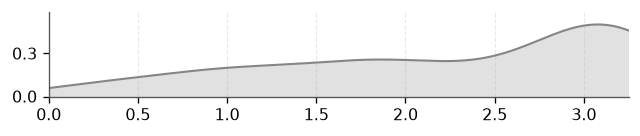

,n_loaded_rows,n_finite_ddG,n_nonfinite_ddG,ddG_min,ddG_q25,ddG_median,ddG_q75,ddG_max,ddG_mean,ddG_std,units,n_raw_input_rows,n_rows_removed_by_loader
0,103,103,0,0.142885,1.604948,2.479302,3.136197,3.136197,2.242338,0.955787,kcal/mol,103,0


,component,n_unique_valid_structures,n_valid_records,n_missing_records,n_invalid_records
0,Reactant SMILES,55,103,0,0
1,Product SMILES,55,103,0,0
2,Additive SMILES,12,84,19,0
3,Solvent SMILES,10,103,0,0
4,Ligand SMILES,12,103,0,0


In [3]:
# External-set characterization: independent of features and prediction.
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

def summarize_external_set(frame):
    values = pd.to_numeric(frame["ddG"], errors="coerce").to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if not len(finite):
        raise ValueError("External dataset has no finite ddG values.")
    q = np.quantile(finite, [0, .25, .5, .75, 1])
    summary = pd.DataFrame([{
        "n_loaded_rows": len(frame), "n_finite_ddG": len(finite),
        "n_nonfinite_ddG": len(values)-len(finite),
        "ddG_min": q[0], "ddG_q25": q[1], "ddG_median": q[2],
        "ddG_q75": q[3], "ddG_max": q[4], "ddG_mean": finite.mean(),
        "ddG_std": finite.std(ddof=1) if len(finite)>1 else np.nan,
        "units": "kcal/mol",
    }])
    rows = []
    for column in COMPONENT_COLS:
        valid, missing, invalid = [], 0, 0
        for value in frame[column]:
            if pd.isna(value) or str(value).strip().lower() in {"", "nan", "none", "null"}:
                missing += 1
                continue
            mol = Chem.MolFromSmiles(str(value))
            if mol is None:
                invalid += 1
            else:
                valid.append(Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True))
        rows.append({"component": column, "n_unique_valid_structures": len(set(valid)),
                     "n_valid_records": len(valid), "n_missing_records": missing,
                     "n_invalid_records": invalid})
    return finite, summary, pd.DataFrame(rows)


def draw_external_ddg_distribution(values, show_text=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2 or np.isclose(np.std(values), 0.0):
        raise ValueError("KDE requires at least two finite, nonconstant ddG values.")
    lo = min(0.0, float(np.floor(values.min()*4)/4))
    hi = float(np.ceil(values.max()*4)/4)
    if hi <= lo:
        hi = lo + 1.0
    x = np.linspace(lo, hi, EXTERNAL_DDG_N_GRID)
    density = gaussian_kde(values, bw_method=EXTERNAL_DDG_BW_METHOD)(x)
    table = pd.DataFrame({"x_ddG": x, "density": density})
    fig, ax = plt.subplots(figsize=DDG_FIGSIZE)
    ax.fill_between(x, 0, density, color=EXTERNAL_DDG_COLOR, alpha=.24, linewidth=0)
    ax.plot(x, density, color=EXTERNAL_DDG_COLOR, linewidth=1.25)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0, float(density.max())*1.18)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=2, min_n_ticks=2))
    ax.tick_params(labelsize=9.5, length=3.5, width=.8)
    ax.spines[['top', 'right']].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_color('#555555')
        ax.spines[side].set_linewidth(.8)
    ax.grid(axis='x', color='#B8B8B8', alpha=.32, linestyle='--', linewidth=.7)
    if show_text:
        ax.set_xlabel(r'$\Delta\Delta G^{\ddagger}$ (kcal/mol)')
        ax.set_ylabel('Probability density')
        ax.set_title(f'External validation set · {len(values)} reactions')
    if SHOW_LEGEND:
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(facecolor='#D0D0D0', edgecolor=EXTERNAL_DDG_COLOR,
                                 label='External Ru-AHO')], frameon=False)
    fig.tight_layout(pad=.25)
    return fig, table

external_ddg, external_ddg_summary, external_structure_summary = summarize_external_set(recent_ready)
external_ddg_summary['n_raw_input_rows'] = len(df_recent)
external_ddg_summary['n_rows_removed_by_loader'] = len(df_recent)-len(recent_ready)
external_ddg_summary.to_csv(TABLE_DIR/'external_ddg_summary.csv', index=False)
external_structure_summary.to_csv(TABLE_DIR/'external_structure_summary.csv', index=False)
pd.DataFrame({'record_id': recent_ready['record_id'], 'ddG': recent_ready['ddG']}).to_csv(
    TABLE_DIR/'external_ddg_values.csv', index=False)
fig, external_ddg_density = draw_external_ddg_distribution(external_ddg, SHOW_TEXT)
external_ddg_density.to_csv(TABLE_DIR/'external_ddg_density.csv', index=False)
suffix = 'with_text' if SHOW_TEXT else 'no_text'
fig.savefig(FIGURE_DIR/f'external_ddg_distribution_{suffix}.svg', bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
display(external_ddg_summary)
display(external_structure_summary)
if len(external_ddg) != 103:
    print(f'Note: loaded {len(external_ddg)} finite external values; manuscript draft states 103. Check data version before layout.')


In [4]:
# =========================
# Descriptor builders aligned with 1_1 (MACCS) and 1_2 (SPOC)
# =========================
def _bitvect_to_pm1(bitvect, nbits: int) -> np.ndarray:
    arr = np.zeros((nbits,), dtype=np.int8)
    ConvertToNumpyArray(bitvect, arr)
    return np.where(arr > 0, 1, -1).astype(np.float32)


def build_maccs_pm1_vector(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles.strip() else None
    if mol is None:
        return -np.ones((MACCS_LENGTH,), dtype=np.float32)
    return _bitvect_to_pm1(rdMolDescriptors.GetMACCSKeysFingerprint(mol), MACCS_LENGTH)


def build_maccs_1_1_matrix(df: pd.DataFrame) -> np.ndarray:
    """1_1 representation: five −1/+1 MACCS blocks plus three numeric conditions."""
    molecule_cache = {}
    rows = []
    for _, row in df.iterrows():
        blocks = []
        for col in COMPONENT_COLS:
            smiles = str(row[col]) if pd.notna(row[col]) else ""
            if smiles not in molecule_cache:
                molecule_cache[smiles] = build_maccs_pm1_vector(smiles)
            blocks.append(molecule_cache[smiles])
        rows.append(np.concatenate(blocks))
    x_maccs = np.asarray(rows, dtype=np.float32)
    x_conditions = (
        df[COND_COLS]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=np.float32)
    )
    return np.concatenate([x_maccs, x_conditions], axis=1).astype(np.float32)


DESC_LIST = list(Descriptors._descList)
DESC_NAMES = [name for name, _ in DESC_LIST]
SPOC_COMPONENT_PREFIXES = OrderedDict([
    ("Reactant SMILES", "reactant"),
    ("Product SMILES", "product"),
    ("Ligand SMILES", "ligand"),
    ("Solvent SMILES", "solvent"),
    ("Additive SMILES", "additive"),
])


def smiles_to_mol(smiles: str):
    if smiles is None or str(smiles).strip() == "":
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def spoc_maccs_array(mol) -> np.ndarray:
    arr = np.zeros((MACCS_LENGTH,), dtype=np.float32)
    if mol is None:
        return arr
    try:
        ConvertToNumpyArray(MACCSkeys.GenMACCSKeys(mol), arr)
    except Exception:
        arr[:] = np.nan
    return arr


def rdkit_descriptor_array(mol) -> np.ndarray:
    values = []
    for _, fn in DESC_LIST:
        if mol is None:
            values.append(np.nan)
            continue
        try:
            values.append(float(fn(mol)))
        except Exception:
            values.append(np.nan)
    return np.asarray(values, dtype=np.float32)


def build_component_spoc(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    maccs_rows, descriptor_rows = [], []
    for smiles in df[col].astype(str).tolist():
        mol = smiles_to_mol(smiles)
        maccs_rows.append(spoc_maccs_array(mol))
        descriptor_rows.append(rdkit_descriptor_array(mol))
    maccs_df = pd.DataFrame(
        np.vstack(maccs_rows),
        columns=[f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_LENGTH)],
        index=df.index,
    )
    descriptor_df = pd.DataFrame(
        np.vstack(descriptor_rows),
        columns=[f"{prefix}__RDKit_{name}" for name in DESC_NAMES],
        index=df.index,
    )
    return pd.concat([maccs_df, descriptor_df], axis=1)


def expected_spoc_feature_columns(df: pd.DataFrame) -> list[str]:
    columns = []
    for _, prefix in SPOC_COMPONENT_PREFIXES.items():
        columns.extend([f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_LENGTH)])
        columns.extend([f"{prefix}__RDKit_{name}" for name in DESC_NAMES])
    columns.extend([f"condition__{col}" for col in COND_COLS])
    label_columns = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    ).columns.astype(str).tolist()
    columns.extend(label_columns)
    return columns


def build_spoc_1_2_matrix(df: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    pieces = []
    for col, prefix in SPOC_COMPONENT_PREFIXES.items():
        print(f"Building SPOC component descriptors: {prefix}")
        pieces.append(build_component_spoc(df, col, prefix))
    condition_df = df[COND_COLS].apply(pd.to_numeric, errors="coerce")
    condition_df.columns = [f"condition__{col}" for col in condition_df.columns]
    pieces.append(condition_df)
    label_df = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    )
    pieces.append(label_df)
    x_df = pd.concat(pieces, axis=1).replace([np.inf, -np.inf], np.nan)
    return x_df.to_numpy(dtype=np.float32), list(x_df.columns)


In [5]:
# =========================
# Build or reuse separate MACCS and SPOC matrices
# =========================
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_ndarray(array: np.ndarray) -> str:
    array = np.ascontiguousarray(array)
    digest = hashlib.sha256()
    digest.update(str(array.shape).encode())
    digest.update(str(array.dtype).encode())
    digest.update(array.view(np.uint8))
    return digest.hexdigest()


MACCS_MATRIX_PATH = FEATURE_CACHE_DIR / "maccs_external_validation_feature_matrix.npy"
SPOC_MATRIX_PATH = FEATURE_CACHE_DIR / "spoc_external_validation_feature_matrix.npy"
EXPECTED_MACCS_SHAPE = (len(combined_df), MACCS_LENGTH * len(COMPONENT_COLS) + len(COND_COLS))
EXPECTED_SPOC_COLUMNS = expected_spoc_feature_columns(combined_df)
EXPECTED_SPOC_SHAPE = (len(combined_df), len(EXPECTED_SPOC_COLUMNS))


def load_npy_if_valid(path: Path, expected_shape: tuple[int, int], force: bool):
    if force:
        return None, "forced_rebuild"
    if not path.exists():
        return None, "missing"
    try:
        matrix = np.load(path)
    except Exception as exc:
        return None, f"load_failed: {exc}"
    if matrix.shape != expected_shape:
        return None, f"shape_mismatch_{matrix.shape}_expected_{expected_shape}"
    return matrix.astype(np.float32, copy=False), "loaded"


X_MACCS_ALL, MACCS_CACHE_STATUS = load_npy_if_valid(
    MACCS_MATRIX_PATH, EXPECTED_MACCS_SHAPE, FORCE_REBUILD_MACCS
)
if X_MACCS_ALL is None:
    X_MACCS_ALL = build_maccs_1_1_matrix(combined_df)
    if X_MACCS_ALL.shape != EXPECTED_MACCS_SHAPE:
        raise RuntimeError(f"Unexpected MACCS matrix shape: {X_MACCS_ALL.shape}")
    np.save(MACCS_MATRIX_PATH, X_MACCS_ALL)
    MACCS_CACHE_STATUS = "built_and_saved"

X_SPOC_ALL, SPOC_CACHE_STATUS = load_npy_if_valid(
    SPOC_MATRIX_PATH, EXPECTED_SPOC_SHAPE, FORCE_REBUILD_SPOC
)
if X_SPOC_ALL is None:
    X_SPOC_ALL, SPOC_FEATURE_COLUMNS = build_spoc_1_2_matrix(combined_df)
    if SPOC_FEATURE_COLUMNS != EXPECTED_SPOC_COLUMNS:
        raise RuntimeError("SPOC columns differ from the 1_2-aligned expected columns.")
    np.save(SPOC_MATRIX_PATH, X_SPOC_ALL)
    SPOC_CACHE_STATUS = "built_and_saved"
else:
    SPOC_FEATURE_COLUMNS = EXPECTED_SPOC_COLUMNS


def split_blocks(matrix: np.ndarray) -> dict[str, np.ndarray]:
    return {
        "target": matrix[:n_aho],
        "same_source": matrix[n_aho:n_aho + n_same],
        "different_source": matrix[n_aho + n_same:n_aho + n_same + n_diff],
        "external": matrix[n_aho + n_same + n_diff:],
    }


FEATURES = {
    "MACCS": split_blocks(X_MACCS_ALL),
    "SPOC": split_blocks(X_SPOC_ALL),
}

for representation, blocks in FEATURES.items():
    if blocks["external"].shape[0] != n_recent:
        raise RuntimeError(f"{representation} external feature-row split is inconsistent.")

FEATURE_HASHES = {
    "MACCS": sha256_ndarray(X_MACCS_ALL),
    "SPOC": sha256_ndarray(X_SPOC_ALL),
}
INPUT_HASHES = {label: sha256_file(path) for label, path in input_paths.items()}
CACHE_KEY_METADATA = {
    "maccs_descriptor_version": MACCS_DESCRIPTOR_VERSION,
    "spoc_descriptor_version": SPOC_DESCRIPTOR_VERSION,
    "feature_hashes": FEATURE_HASHES,
    "input_hashes": INPUT_HASHES,
    "row_counts": {"target": n_aho, "same_source": n_same, "different_source": n_diff, "external": n_recent},
}
CACHE_KEY_SHA256 = hashlib.sha256(
    json.dumps(CACHE_KEY_METADATA, sort_keys=True).encode("utf-8")
).hexdigest()

print("MACCS:", X_MACCS_ALL.shape, MACCS_CACHE_STATUS, "NaN =", int(np.isnan(X_MACCS_ALL).sum()))
print("SPOC :", X_SPOC_ALL.shape, SPOC_CACHE_STATUS, "NaN =", int(np.isnan(X_SPOC_ALL).sum()))
print("Feature cache key:", CACHE_KEY_SHA256[:16])


Building SPOC component descriptors: reactant
Building SPOC component descriptors: product
Building SPOC component descriptors: ligand
Building SPOC component descriptors: solvent
Building SPOC component descriptors: additive
MACCS: (2235, 838) built_and_saved NaN = 0
SPOC : (2235, 2044) built_and_saved NaN = 79211
Feature cache key: 06e53ccefc7599a9


In [6]:
# =========================
# Select representation-balanced ensemble members from notebooks 1.1 and 1.2
# =========================
MODEL_SHORT_NAMES = {
    "AdaBoostRegressor": "ABR",
    "ExtraTreesRegressor": "ExtraTrees",
    "GradientBoostingRegressor": "GBR",
    "HistGradientBoostingRegressor": "HGBR",
    "RandomForestRegressor": "RF",
    "GaussianProcessRegressor": "GPR",
    "KNeighborsRegressor": "KNN",
    "SVR": "SVR",
    "LinearSVR": "LinearSVR",
    "DecisionTreeRegressor": "DT",
    "ExtraTreeRegressor": "ExtraTree",
}
METHOD_TO_STRATEGY = {
    "Target-only": "target-only",
    "Mixed transfer": "mixed-transfer",
    "Delta learning": "delta-learning",
}
STRATEGY_SHORT_NAMES = {
    "target-only": "Target-only",
    "mixed-transfer": "Mixed",
    "delta-learning": "Delta",
}


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_benchmark_metrics(path: Path, representation: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Run notebook 1.1/1.2 before external validation. Missing: {path}"
        )

    table = pd.read_csv(path)
    required_columns = {
        "model",
        "task_id",
        "source_domain",
        "relation_label",
        "method_label",
        "R2",
        "MAE",
        "RMSE",
    }
    missing = required_columns - set(table.columns)
    if missing:
        raise KeyError(
            f"{representation} benchmark table is missing columns: {sorted(missing)}"
        )

    table = table.copy()
    table["representation"] = representation
    for column in ["R2", "MAE", "RMSE"]:
        table[column] = pd.to_numeric(table[column], errors="coerce")

    table = table.loc[np.isfinite(table["R2"])].copy()
    if table.empty:
        raise ValueError(f"{representation} benchmark table contains no finite R² values.")

    return table.reset_index(drop=True)


BENCHMARK_TABLES = OrderedDict(
    (
        representation,
        load_benchmark_metrics(path, representation),
    )
    for representation, path in BENCHMARK_METRICS_PATHS.items()
)
COMBINED_BENCHMARK_METRICS = pd.concat(
    BENCHMARK_TABLES.values(),
    ignore_index=True,
)

BENCHMARK_INPUT_AUDIT = pd.DataFrame(
    [
        {
            "representation": representation,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "sha256": sha256_file(path),
            "rows": len(BENCHMARK_TABLES[representation]),
        }
        for representation, path in BENCHMARK_METRICS_PATHS.items()
    ]
)
BENCHMARK_INPUT_AUDIT.to_csv(
    TABLE_DIR / "benchmark_metric_input_audit.csv",
    index=False,
)
display(BENCHMARK_INPUT_AUDIT)


def scenario_candidate_pool(
    benchmark_metrics: pd.DataFrame,
    scenario_name: str,
) -> pd.DataFrame:
    method = benchmark_metrics["method_label"].astype(str)
    relation = benchmark_metrics["relation_label"].astype(str)

    if scenario_name == TARGET_ONLY_NAME:
        mask = method.eq("Target-only")
    elif scenario_name == SAME_MECH_NAME:
        mask = (
            relation.str.casefold().eq("same mechanism")
            & method.isin(["Mixed transfer", "Delta learning"])
        )
    elif scenario_name == DIFF_MECH_NAME:
        mask = (
            relation.str.casefold().eq("different mechanism")
            & method.isin(["Mixed transfer", "Delta learning"])
        )
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    pool = benchmark_metrics.loc[mask].copy()
    pool = pool.drop_duplicates(
        subset=[
            "representation",
            "model",
            "task_id",
            "method_label",
            "source_domain",
        ],
        keep="first",
    )

    pool = pool.sort_values(
        [
            "representation",
            "R2",
            "MAE",
            "RMSE",
            "model",
            "method_label",
        ],
        ascending=[True, False, True, True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)

    pool["representation_rank"] = (
        pool.groupby("representation", sort=False).cumcount() + 1
    )
    overall_order = pool.sort_values(
        [
            "R2",
            "MAE",
            "RMSE",
            "representation",
            "model",
            "method_label",
        ],
        ascending=[False, True, True, True, True, True],
        kind="mergesort",
    ).index
    overall_rank = pd.Series(
        np.arange(1, len(pool) + 1, dtype=int),
        index=overall_order,
    )
    pool["overall_rank"] = overall_rank.sort_index().to_numpy()

    for representation, required_size in (
        ENSEMBLE_SIZE_BY_REPRESENTATION.items()
    ):
        available = int(pool["representation"].eq(representation).sum())
        if available < required_size:
            raise ValueError(
                f"{SCENARIO_LABELS[scenario_name]} has only {available} "
                f"eligible {representation} settings; {required_size} are required."
            )

    return pool


def safe_name(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")


def benchmark_row_to_member(
    scenario_name: str,
    row: pd.Series,
) -> dict:
    method_label = str(row["method_label"])
    if method_label not in METHOD_TO_STRATEGY:
        raise ValueError(f"Unsupported benchmark method: {method_label!r}")

    representation = str(row["representation"])
    model_name = str(row["model"])
    strategy = METHOD_TO_STRATEGY[method_label]

    member_id = safe_name(
        "__".join(
            [
                scenario_name,
                representation,
                model_name,
                strategy,
            ]
        )
    )

    return {
        "member_id": member_id,
        "ensemble_position": int(row["ensemble_position"]),
        "rank": int(row["representation_rank"]),
        "representation_rank": int(row["representation_rank"]),
        "overall_rank": int(row["overall_rank"]),
        "representation_quota": int(
            ENSEMBLE_SIZE_BY_REPRESENTATION[representation]
        ),
        "representation": representation,
        "model": model_name,
        "strategy": strategy,
        "method_label": method_label,
        "task_id": str(row["task_id"]),
        "source_domain": str(row["source_domain"]),
        "oof_R2": float(row["R2"]),
        "oof_MAE": float(row["MAE"]),
        "oof_RMSE": float(row["RMSE"]),
    }


SCENARIO_METADATA = {
    TARGET_ONLY_NAME: {
        "source_key": None,
        "source_domain": "none",
    },
    SAME_MECH_NAME: {
        "source_key": "same_source",
        "source_domain": "Ru-AHK inner",
    },
    DIFF_MECH_NAME: {
        "source_key": "different_source",
        "source_domain": "Ru-AHK outer",
    },
}

CANDIDATE_POOLS = OrderedDict()
ENSEMBLE_SPECS = OrderedDict()
selection_rows = []

for scenario_name in SCENARIO_LABELS:
    pool = scenario_candidate_pool(
        COMBINED_BENCHMARK_METRICS,
        scenario_name,
    )
    CANDIDATE_POOLS[scenario_name] = pool

    selected_parts = []
    for representation, required_size in (
        ENSEMBLE_SIZE_BY_REPRESENTATION.items()
    ):
        if required_size == 0:
            continue
        representation_selection = (
            pool.loc[pool["representation"].eq(representation)]
            .sort_values(
                [
                    "representation_rank",
                    "R2",
                    "MAE",
                    "RMSE",
                    "model",
                    "method_label",
                ],
                ascending=[True, False, True, True, True, True],
                kind="mergesort",
            )
            .head(required_size)
            .copy()
        )
        selected_parts.append(representation_selection)

    selected_rows = pd.concat(
        selected_parts,
        ignore_index=True,
    )
    selected_rows["representation_order"] = (
        selected_rows["representation"].map(
            {
                representation: order
                for order, representation in enumerate(
                    ENSEMBLE_SIZE_BY_REPRESENTATION
                )
            }
        )
    )
    selected_rows = selected_rows.sort_values(
        ["representation_order", "representation_rank"],
        kind="mergesort",
    ).reset_index(drop=True)
    selected_rows["ensemble_position"] = np.arange(
        1,
        len(selected_rows) + 1,
        dtype=int,
    )

    if len(selected_rows) != ENSEMBLE_SIZE:
        raise RuntimeError(
            f"Selected {len(selected_rows)} members; expected {ENSEMBLE_SIZE}."
        )

    selected_counts = (
        selected_rows["representation"].value_counts().to_dict()
    )
    expected_counts = {
        representation: required_size
        for representation, required_size in ENSEMBLE_SIZE_BY_REPRESENTATION.items()
        if required_size > 0
    }
    if selected_counts != expected_counts:
        raise RuntimeError(
            f"Representation composition mismatch: "
            f"selected={selected_counts}, expected={expected_counts}"
        )

    members = [
        benchmark_row_to_member(scenario_name, row)
        for _, row in selected_rows.iterrows()
    ]

    ENSEMBLE_SPECS[scenario_name] = {
        **SCENARIO_METADATA[scenario_name],
        "members": members,
    }

    for member_spec in members:
        selection_rows.append(
            {
                "scenario_id": scenario_name,
                "scenario": SCENARIO_LABELS[scenario_name],
                **member_spec,
            }
        )

CANDIDATE_POOL_DF = pd.concat(
    [
        pool.assign(
            scenario_id=scenario_name,
            scenario=SCENARIO_LABELS[scenario_name],
        )
        for scenario_name, pool in CANDIDATE_POOLS.items()
    ],
    ignore_index=True,
)
SELECTION_DF = pd.DataFrame(selection_rows)

CANDIDATE_POOL_PATH = (
    TABLE_DIR / "benchmark_ranked_candidate_pool.csv"
)
SELECTION_PATH = (
    TABLE_DIR / f"selected_{ENSEMBLE_TAG}_member_ensembles.csv"
)

CANDIDATE_POOL_DF.to_csv(
    CANDIDATE_POOL_PATH,
    index=False,
)
SELECTION_DF.to_csv(
    SELECTION_PATH,
    index=False,
)

SELECTION_SHA256 = hashlib.sha256(
    SELECTION_DF.sort_values(
        ["scenario_id", "ensemble_position"]
    ).to_json(
        orient="records",
        double_precision=15,
    ).encode("utf-8")
).hexdigest()

MODEL_CACHE_KEY_SHA256 = hashlib.sha256(
    (
        CACHE_KEY_SHA256
        + "|"
        + SELECTION_SHA256
        + "|"
        + MODEL_CACHE_VERSION
    ).encode("utf-8")
).hexdigest()

N_SCENARIOS = len(ENSEMBLE_SPECS)
N_SELECTED_MEMBERS = sum(
    len(specification["members"])
    for specification in ENSEMBLE_SPECS.values()
)
N_TOTAL_RESULTS = N_SELECTED_MEMBERS + N_SCENARIOS

print(
    f"Automatically selected {ENSEMBLE_DISPLAY} members for each of "
    f"{N_SCENARIOS} scenarios from the current 1.1 and 1.2 pooled OOF tables."
)
display(SELECTION_DF)


def make_mean_imputer():
    try:
        return SimpleImputer(
            strategy="mean",
            keep_empty_features=True,
        )
    except TypeError:
        return SimpleImputer(strategy="mean")


def make_model(representation: str, model_name: str):
    if representation == "MACCS":
        factories = {
            "AdaBoostRegressor": lambda: AdaBoostRegressor(
                random_state=RANDOM_STATE
            ),
            "ExtraTreesRegressor": lambda: ExtraTreesRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            "GradientBoostingRegressor": lambda: GradientBoostingRegressor(
                random_state=RANDOM_STATE
            ),
            "HistGradientBoostingRegressor": lambda: HistGradientBoostingRegressor(
                random_state=RANDOM_STATE
            ),
            "RandomForestRegressor": lambda: RandomForestRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            "GaussianProcessRegressor": lambda: make_pipeline(
                StandardScaler(),
                GaussianProcessRegressor(
                    normalize_y=True,
                    alpha=1e-6,
                    random_state=RANDOM_STATE,
                ),
            ),
            "KNeighborsRegressor": lambda: make_pipeline(
                StandardScaler(),
                KNeighborsRegressor(),
            ),
            "SVR": lambda: make_pipeline(
                StandardScaler(),
                SVR(),
            ),
            "LinearSVR": lambda: make_pipeline(
                StandardScaler(),
                LinearSVR(
                    random_state=RANDOM_STATE,
                    max_iter=5000,
                ),
            ),
            "DecisionTreeRegressor": lambda: DecisionTreeRegressor(
                random_state=RANDOM_STATE
            ),
            "ExtraTreeRegressor": lambda: ExtraTreeRegressor(
                random_state=RANDOM_STATE
            ),
        }
    elif representation == "SPOC":
        non_scaled_factories = {
            "AdaBoostRegressor": lambda: AdaBoostRegressor(
                random_state=RANDOM_STATE
            ),
            "ExtraTreesRegressor": lambda: ExtraTreesRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            "GradientBoostingRegressor": lambda: GradientBoostingRegressor(
                random_state=RANDOM_STATE
            ),
            "HistGradientBoostingRegressor": lambda: HistGradientBoostingRegressor(
                random_state=RANDOM_STATE
            ),
            "RandomForestRegressor": lambda: RandomForestRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            "DecisionTreeRegressor": lambda: DecisionTreeRegressor(
                random_state=RANDOM_STATE
            ),
            "ExtraTreeRegressor": lambda: ExtraTreeRegressor(
                random_state=RANDOM_STATE
            ),
        }
        scaled_factories = {
            "GaussianProcessRegressor": lambda: GaussianProcessRegressor(
                normalize_y=True,
                alpha=1e-6,
                random_state=RANDOM_STATE,
            ),
            "KNeighborsRegressor": lambda: KNeighborsRegressor(),
            "SVR": lambda: SVR(),
            "LinearSVR": lambda: LinearSVR(
                random_state=RANDOM_STATE,
                max_iter=5000,
            ),
        }

        if model_name in non_scaled_factories:
            return make_pipeline(
                make_mean_imputer(),
                non_scaled_factories[model_name](),
            )
        if model_name in scaled_factories:
            return make_pipeline(
                make_mean_imputer(),
                StandardScaler(),
                scaled_factories[model_name](),
            )
        raise KeyError(f"Unsupported SPOC model: {model_name}")
    else:
        raise KeyError(f"Unknown representation: {representation}")

    if model_name not in factories:
        raise KeyError(f"Unsupported MACCS model: {model_name}")
    return factories[model_name]()


def predict_1d(model, x):
    return np.asarray(model.predict(x), dtype=float).reshape(-1)


def predict_member(member_bundle: dict, x: np.ndarray) -> np.ndarray:
    strategy = member_bundle["strategy"]
    if strategy in {"target-only", "mixed-transfer"}:
        return predict_1d(member_bundle["model_object"], x)
    if strategy == "delta-learning":
        return (
            predict_1d(member_bundle["source_model"], x)
            + predict_1d(member_bundle["delta_model"], x)
        )
    raise ValueError(f"Unknown strategy: {strategy}")


def member_display_name(spec: dict) -> str:
    model_label = MODEL_SHORT_NAMES.get(spec["model"], spec["model"])
    return (
        f"{spec['representation']} #{spec['representation_rank']} "
        f"{model_label} {STRATEGY_SHORT_NAMES[spec['strategy']]}"
    )


def member_result_name(scenario_name: str, spec: dict) -> str:
    return f"{SCENARIO_LABELS[scenario_name]} | {member_display_name(spec)}"


def ensemble_result_name(scenario_name: str) -> str:
    return (
        f"{SCENARIO_LABELS[scenario_name]} | "
        f"{ENSEMBLE_DISPLAY} ensemble mean"
    )


,representation,path,sha256,rows
0,MACCS,results/1_1_maccs_mechanism_transfer/tables/ma...,aa46bb0cec2e65912d20b54f184cebe41b1bc838e5d004...,50
1,SPOC,results/1_2_spoc_mechanism_transfer/tables/spo...,5bbaac2f6931c410d92974c9a0dd4912cde1d1124e5fb9...,50


Automatically selected 3 MACCS + 3 SPOC members for each of 3 scenarios from the current 1.1 and 1.2 pooled OOF tables.


,scenario_id,scenario,member_id,ensemble_position,rank,representation_rank,overall_rank,representation_quota,representation,model,strategy,method_label,task_id,source_domain,oof_R2,oof_MAE,oof_RMSE
0,target_only,Target-only,target_only_maccs_svr_target_only,1,1,1,4,3,MACCS,SVR,target-only,Target-only,target_only_ru_aho_inner,none,0.495043,0.452117,0.672032
1,target_only,Target-only,target_only_maccs_histgradientboostingregresso...,2,2,2,6,3,MACCS,HistGradientBoostingRegressor,target-only,Target-only,target_only_ru_aho_inner,none,0.482109,0.465376,0.680584
2,target_only,Target-only,target_only_maccs_gradientboostingregressor_ta...,3,3,3,7,3,MACCS,GradientBoostingRegressor,target-only,Target-only,target_only_ru_aho_inner,none,0.467606,0.432770,0.690048
3,target_only,Target-only,target_only_spoc_gradientboostingregressor_tar...,4,1,1,1,3,SPOC,GradientBoostingRegressor,target-only,Target-only,target_only_ru_aho_inner,none,0.621655,0.405804,0.581710
4,target_only,Target-only,target_only_spoc_histgradientboostingregressor...,5,2,2,2,3,SPOC,HistGradientBoostingRegressor,target-only,Target-only,target_only_ru_aho_inner,none,0.542136,0.467513,0.639928
5,target_only,Target-only,target_only_spoc_randomforestregressor_target_...,6,3,3,3,3,SPOC,RandomForestRegressor,target-only,Target-only,target_only_ru_aho_inner,none,0.500892,0.447341,0.668129
6,mechanism_aligned_transfer,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_extratreesreg...,1,1,1,4,3,MACCS,ExtraTreesRegressor,mixed-transfer,Mixed transfer,ru_ahk_inner_to_ru_aho_inner,inner,0.640186,0.350487,0.567286
7,mechanism_aligned_transfer,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_histgradientb...,2,2,2,6,3,MACCS,HistGradientBoostingRegressor,mixed-transfer,Mixed transfer,ru_ahk_inner_to_ru_aho_inner,inner,0.632018,0.413710,0.573688
8,mechanism_aligned_transfer,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_decisiontreer...,3,3,3,8,3,MACCS,DecisionTreeRegressor,delta-learning,Delta learning,ru_ahk_inner_to_ru_aho_inner,inner,0.619220,0.389602,0.583579
9,mechanism_aligned_transfer,Mechanism-aligned transfer,mechanism_aligned_transfer_spoc_histgradientbo...,4,1,1,1,3,SPOC,HistGradientBoostingRegressor,mixed-transfer,Mixed transfer,ru_ahk_inner_to_ru_aho_inner,inner,0.702908,0.352521,0.515476


In [7]:
# =========================
# Retrain the benchmark-selected members and construct one ensemble per scenario
# =========================
def train_member_bundle(
    scenario_name: str,
    scenario_spec: dict,
    spec: dict,
) -> dict:
    representation = spec["representation"]
    strategy = spec["strategy"]
    x_target = FEATURES[representation]["target"]
    x_external = FEATURES[representation]["external"]

    bundle = {
        "cache_version": MODEL_CACHE_VERSION,
        "model_cache_key_sha256": MODEL_CACHE_KEY_SHA256,
        "selection_sha256": SELECTION_SHA256,
        "scenario_name": scenario_name,
        "scenario": SCENARIO_LABELS[scenario_name],
        "member_spec": dict(spec),
        "representation": representation,
        "strategy": strategy,
        "source_domain": scenario_spec["source_domain"],
        "target_domain": "Ru-AHO inner",
        "n_features": int(x_target.shape[1]),
        "n_target": int(len(y_aho)),
        "n_source": (
            0
            if scenario_spec["source_key"] is None
            else int(
                len(y_ahk_same)
                if scenario_spec["source_key"] == "same_source"
                else len(y_ahk_diff)
            )
        ),
    }

    if strategy == "target-only":
        model = make_model(representation, spec["model"])
        model.fit(x_target, y_aho)
        bundle["model_object"] = model
    else:
        source_key = scenario_spec["source_key"]
        if source_key is None:
            raise ValueError(f"Transfer member has no source domain: {spec}")

        x_source = FEATURES[representation][source_key]
        y_source = (
            y_ahk_same
            if source_key == "same_source"
            else y_ahk_diff
        )

        if strategy == "mixed-transfer":
            model = make_model(representation, spec["model"])
            model.fit(
                np.vstack([x_source, x_target]),
                np.concatenate([y_source, y_aho]),
            )
            bundle["model_object"] = model
        elif strategy == "delta-learning":
            source_model = make_model(representation, spec["model"])
            source_model.fit(x_source, y_source)

            source_on_target = predict_1d(source_model, x_target)
            delta_model = make_model(representation, spec["model"])
            delta_model.fit(
                x_target,
                y_aho - source_on_target,
            )
            bundle["source_model"] = source_model
            bundle["delta_model"] = delta_model
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

    probe = predict_member(bundle, x_external[:1])
    if probe.shape != (1,):
        raise RuntimeError(
            f"Unexpected prediction shape for {spec['member_id']}: {probe.shape}"
        )
    return bundle


def member_model_path(spec: dict) -> Path:
    return MODEL_DIR / (
        f"member_{safe_name(spec['member_id'])}_"
        f"{SELECTION_SHA256[:12]}.joblib"
    )


def ensemble_model_path(scenario_name: str) -> Path:
    return MODEL_DIR / (
        f"ensemble_{safe_name(scenario_name)}_"
        f"{SELECTION_SHA256[:12]}.joblib"
    )


def cached_member_is_usable(
    bundle: dict,
    scenario_name: str,
    spec: dict,
) -> tuple[bool, str]:
    if not isinstance(bundle, dict):
        return False, "not_dict"

    checks = [
        (
            bundle.get("cache_version") == MODEL_CACHE_VERSION,
            "cache_version",
        ),
        (
            bundle.get("model_cache_key_sha256") == MODEL_CACHE_KEY_SHA256,
            "model_cache_key",
        ),
        (
            bundle.get("selection_sha256") == SELECTION_SHA256,
            "selection_hash",
        ),
        (
            bundle.get("scenario_name") == scenario_name,
            "scenario_name",
        ),
        (
            bundle.get("member_spec", {}).get("member_id") == spec["member_id"],
            "member_id",
        ),
        (
            bundle.get("representation") == spec["representation"],
            "representation",
        ),
        (
            bundle.get("strategy") == spec["strategy"],
            "strategy",
        ),
        (
            int(bundle.get("n_features", -1))
            == FEATURES[spec["representation"]]["external"].shape[1],
            "n_features",
        ),
    ]
    for passed, label in checks:
        if not passed:
            return False, f"{label}_mismatch"

    try:
        prediction = predict_member(
            bundle,
            FEATURES[spec["representation"]]["external"][:1],
        )
        if prediction.shape != (1,):
            return False, "prediction_shape"
    except Exception as exc:
        return False, f"prediction_failed: {exc}"

    return True, "loaded_valid"


EXPECTED_MODEL_PATHS = {
    ensemble_model_path(scenario_name)
    for scenario_name in ENSEMBLE_SPECS
}
for scenario_spec in ENSEMBLE_SPECS.values():
    EXPECTED_MODEL_PATHS.update(
        member_model_path(spec)
        for spec in scenario_spec["members"]
    )

for path in MODEL_DIR.glob("*.joblib"):
    if path not in EXPECTED_MODEL_PATHS:
        cleanup_paths([path])

trained_members = OrderedDict()
member_predictions = OrderedDict()
ensemble_predictions = OrderedDict()
all_predictions = OrderedDict()
cache_status_rows = []

for scenario_name, scenario_spec in ENSEMBLE_SPECS.items():
    scenario_members = OrderedDict()
    scenario_predictions = OrderedDict()

    for spec in scenario_spec["members"]:
        model_path = member_model_path(spec)
        bundle = None
        status = "not_checked"

        if not FORCE_RETRAIN_MODELS and model_path.exists():
            try:
                loaded = joblib.load(model_path)
                usable, status = cached_member_is_usable(
                    loaded,
                    scenario_name,
                    spec,
                )
                if usable:
                    bundle = loaded
            except Exception as exc:
                status = f"load_failed: {exc}"

        if bundle is None:
            bundle = train_member_bundle(
                scenario_name,
                scenario_spec,
                spec,
            )
            joblib.dump(bundle, model_path)
            status = "trained_and_saved"

        scenario_members[spec["member_id"]] = bundle
        x_external = FEATURES[spec["representation"]]["external"]
        prediction = predict_member(bundle, x_external)
        scenario_predictions[spec["member_id"]] = prediction

        result_name = member_result_name(scenario_name, spec)
        all_predictions[result_name] = prediction
        cache_status_rows.append(
            {
                "scenario": SCENARIO_LABELS[scenario_name],
                "member_id": spec["member_id"],
                "status": status,
                "model_path": str(model_path.relative_to(PROJECT_ROOT)),
            }
        )

    stacked = np.vstack(
        [
            scenario_predictions[spec["member_id"]]
            for spec in scenario_spec["members"]
        ]
    )
    ensemble_prediction = stacked.mean(axis=0)

    ensemble_predictions[scenario_name] = ensemble_prediction
    member_predictions[scenario_name] = scenario_predictions
    all_predictions[
        ensemble_result_name(scenario_name)
    ] = ensemble_prediction
    trained_members[scenario_name] = scenario_members

    ensemble_bundle = {
        "cache_version": MODEL_CACHE_VERSION,
        "model_cache_key_sha256": MODEL_CACHE_KEY_SHA256,
        "selection_sha256": SELECTION_SHA256,
        "scenario_name": scenario_name,
        "scenario": SCENARIO_LABELS[scenario_name],
        "aggregation": "unweighted arithmetic mean",
        "ensemble_composition": dict(ENSEMBLE_SIZE_BY_REPRESENTATION),
        "member_ids": [
            spec["member_id"]
            for spec in scenario_spec["members"]
        ],
        "members": scenario_members,
    }
    joblib.dump(
        ensemble_bundle,
        ensemble_model_path(scenario_name),
    )

CACHE_STATUS_DF = pd.DataFrame(cache_status_rows)
CACHE_STATUS_DF.to_csv(
    TABLE_DIR / "model_cache_status.csv",
    index=False,
)
display(CACHE_STATUS_DF)

print(
    f"Saved {N_SELECTED_MEMBERS} selected member bundles and "
    f"{N_SCENARIOS} {ENSEMBLE_DISPLAY} ensemble bundles."
)


,scenario,member_id,status,model_path
0,Target-only,target_only_maccs_svr_target_only,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
1,Target-only,target_only_maccs_histgradientboostingregresso...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
2,Target-only,target_only_maccs_gradientboostingregressor_ta...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
3,Target-only,target_only_spoc_gradientboostingregressor_tar...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
4,Target-only,target_only_spoc_histgradientboostingregressor...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
5,Target-only,target_only_spoc_randomforestregressor_target_...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
6,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_extratreesreg...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
7,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_histgradientb...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
8,Mechanism-aligned transfer,mechanism_aligned_transfer_maccs_decisiontreer...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...
9,Mechanism-aligned transfer,mechanism_aligned_transfer_spoc_histgradientbo...,trained_and_saved,results/2_1_recent_aho_external_validation/mod...


Saved 18 selected member bundles and 3 3 MACCS + 3 SPOC ensemble bundles.


In [8]:
# =========================
# Complete external metrics and predictions for selected members and ensembles
# All metrics are always calculated and exported.
# =========================
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    pearson_r = np.nan
    if len(y_true) >= 2 and np.std(y_true) > 1e-12 and np.std(y_pred) > 1e-12:
        pearson_r = float(np.corrcoef(y_true, y_pred)[0, 1])
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "PearsonR": pearson_r,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


ALL_METRICS_PATH = TABLE_DIR / "external_metrics_all_selected_models.csv"
SINGLE_METRICS_PATH = TABLE_DIR / "external_metrics_selected_members.csv"
ENSEMBLE_METRICS_PATH = (
    TABLE_DIR / f"external_metrics_{ENSEMBLE_TAG}_ensembles.csv"
)
SCENARIO_COMPARISON_PATH = TABLE_DIR / "external_member_ensemble_diagnostics.csv"
PRED_PATH = TABLE_DIR / "external_predictions.csv"

metric_rows = []
for ensemble_name, scenario_spec in ENSEMBLE_SPECS.items():
    scenario = SCENARIO_LABELS[ensemble_name]
    for spec in scenario_spec["members"]:
        result_name = member_result_name(ensemble_name, spec)
        metric_rows.append({
            "result_name": result_name,
            "scenario": scenario,
            "result_type": "single model",
            "rank_within_representation": spec["representation_rank"],
            "overall_rank_from_internal_OOF": spec["overall_rank"],
            "representation": spec["representation"],
            "model": MODEL_SHORT_NAMES[spec["model"]],
            "full_model_name": spec["model"],
            "strategy": STRATEGY_SHORT_NAMES[spec["strategy"]],
            "source_domain": scenario_spec["source_domain"],
            "internal_pooled_OOF_R2": spec["oof_R2"],
            "internal_pooled_OOF_MAE": spec["oof_MAE"],
            "internal_pooled_OOF_RMSE": spec["oof_RMSE"],
            "aggregation": "none",
            **calc_metrics(y_recent, all_predictions[result_name]),
        })

    ensemble_name_full = ensemble_result_name(ensemble_name)
    metric_rows.append({
        "result_name": ensemble_name_full,
        "scenario": scenario,
        "result_type": "ensemble",
        "rank_within_representation": np.nan,
        "overall_rank_from_internal_OOF": np.nan,
        "representation": ENSEMBLE_DISPLAY,
        "model": f"{ENSEMBLE_DISPLAY} ensemble mean",
        "full_model_name": " + ".join(spec["member_id"] for spec in scenario_spec["members"]),
        "strategy": "member-specific",
        "source_domain": scenario_spec["source_domain"],
        "internal_pooled_OOF_R2": np.nan,
        "internal_pooled_OOF_MAE": np.nan,
        "internal_pooled_OOF_RMSE": np.nan,
        "aggregation": "unweighted arithmetic mean",
        **calc_metrics(y_recent, ensemble_predictions[ensemble_name]),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(ALL_METRICS_PATH, index=False)
single_metrics_df = metrics_df.loc[metrics_df["result_type"] == "single model"].reset_index(drop=True)
ensemble_metrics_df = metrics_df.loc[metrics_df["result_type"] == "ensemble"].reset_index(drop=True)
single_metrics_df.to_csv(SINGLE_METRICS_PATH, index=False)
ensemble_metrics_df.to_csv(ENSEMBLE_METRICS_PATH, index=False)

comparison_rows = []
for ensemble_name in ENSEMBLE_SPECS:
    scenario = SCENARIO_LABELS[ensemble_name]
    scenario_metrics = metrics_df.loc[metrics_df["scenario"] == scenario]
    single_rows = scenario_metrics.loc[scenario_metrics["result_type"] == "single model"]
    ensemble_row = scenario_metrics.loc[scenario_metrics["result_type"] == "ensemble"].iloc[0]
    best_single = single_rows.sort_values(["R2", "MAE"], ascending=[False, True]).iloc[0]
    comparison_rows.append({
        "scenario": scenario,
        "best_single_on_external_set": best_single["result_name"],
        "best_single_external_R2": best_single["R2"],
        "best_single_external_MAE": best_single["MAE"],
        "best_single_external_RMSE": best_single["RMSE"],
        "ensemble_external_R2": ensemble_row["R2"],
        "ensemble_external_MAE": ensemble_row["MAE"],
        "ensemble_external_RMSE": ensemble_row["RMSE"],
        "ensemble_minus_best_single_R2": ensemble_row["R2"] - best_single["R2"],
        "ensemble_minus_best_single_MAE": ensemble_row["MAE"] - best_single["MAE"],
        "ensemble_minus_best_single_RMSE": ensemble_row["RMSE"] - best_single["RMSE"],
    })
scenario_comparison_df = pd.DataFrame(comparison_rows)
scenario_comparison_df.to_csv(SCENARIO_COMPARISON_PATH, index=False)

pred_df = recent_ready.copy()
pred_df["y_true"] = y_recent
for result_name, pred in all_predictions.items():
    key = safe_name(result_name)
    pred_df[f"pred_{key}"] = pred
    pred_df[f"abs_error_{key}"] = np.abs(pred - y_recent)
for ensemble_name, scenario_spec in ENSEMBLE_SPECS.items():
    stacked = np.vstack([
        member_predictions[ensemble_name][spec["member_id"]]
        for spec in scenario_spec["members"]
    ])
    pred_df[f"member_prediction_std_{safe_name(ensemble_result_name(ensemble_name))}"] = stacked.std(axis=0, ddof=0)
pred_df.to_csv(PRED_PATH, index=False)

compact_metrics_df = metrics_df[[
    "scenario", "result_type", "rank_within_representation",
    "overall_rank_from_internal_OOF", "representation", "model", "strategy",
    "internal_pooled_OOF_R2", "R2", "PearsonR", "MAE", "RMSE"
]].copy()

print("Selection audit:", SELECTION_PATH.relative_to(PROJECT_ROOT))
print(f"All {N_TOTAL_RESULTS} metrics:", ALL_METRICS_PATH.relative_to(PROJECT_ROOT))
print(f"{N_SELECTED_MEMBERS} member metrics:", SINGLE_METRICS_PATH.relative_to(PROJECT_ROOT))
print(
    f"{N_SCENARIOS} scenario ensemble metrics:",
    ENSEMBLE_METRICS_PATH.relative_to(PROJECT_ROOT),
)
print("Predictions:", PRED_PATH.relative_to(PROJECT_ROOT))
display(compact_metrics_df)
display(scenario_comparison_df)
display(pred_df.head())


Selection audit: results/2_1_recent_aho_external_validation/tables/selected_maccs3_spoc3_member_ensembles.csv
All 21 metrics: results/2_1_recent_aho_external_validation/tables/external_metrics_all_selected_models.csv
18 member metrics: results/2_1_recent_aho_external_validation/tables/external_metrics_selected_members.csv
3 scenario ensemble metrics: results/2_1_recent_aho_external_validation/tables/external_metrics_maccs3_spoc3_ensembles.csv
Predictions: results/2_1_recent_aho_external_validation/tables/external_predictions.csv


,scenario,result_type,rank_within_representation,overall_rank_from_internal_OOF,representation,model,strategy,internal_pooled_OOF_R2,R2,PearsonR,MAE,RMSE
0,Target-only,single model,1.0,4.0,MACCS,SVR,Target-only,0.495043,0.120893,0.560052,0.789567,0.891792
1,Target-only,single model,2.0,6.0,MACCS,HGBR,Target-only,0.482109,0.306939,0.557546,0.666564,0.791824
2,Target-only,single model,3.0,7.0,MACCS,GBR,Target-only,0.467606,0.296740,0.579204,0.642295,0.797629
3,Target-only,single model,1.0,1.0,SPOC,GBR,Target-only,0.621655,-0.299517,0.103785,0.946561,1.084261
4,Target-only,single model,2.0,2.0,SPOC,HGBR,Target-only,0.542136,0.032855,0.290297,0.801383,0.935381
5,Target-only,single model,3.0,3.0,SPOC,RF,Target-only,0.500892,-0.046836,0.285957,0.844624,0.973155
6,Target-only,ensemble,NaN,NaN,3 MACCS + 3 SPOC,3 MACCS + 3 SPOC ensemble mean,member-specific,NaN,0.187802,0.532516,0.747288,0.857183
7,Mechanism-aligned transfer,single model,1.0,4.0,MACCS,ExtraTrees,Mixed,0.640186,-0.118718,0.331598,0.890886,1.006012
8,Mechanism-aligned transfer,single model,2.0,6.0,MACCS,HGBR,Mixed,0.632018,-0.207526,0.515297,0.920965,1.045180
9,Mechanism-aligned transfer,single model,3.0,8.0,MACCS,DT,Delta,0.619220,-2.382589,0.739958,1.483999,1.749312


,scenario,best_single_on_external_set,best_single_external_R2,best_single_external_MAE,best_single_external_RMSE,ensemble_external_R2,ensemble_external_MAE,ensemble_external_RMSE,ensemble_minus_best_single_R2,ensemble_minus_best_single_MAE,ensemble_minus_best_single_RMSE
0,Target-only,Target-only | MACCS #2 HGBR Target-only,0.306939,0.666564,0.791824,0.187802,0.747288,0.857183,-0.119137,0.080724,0.065359
1,Mechanism-aligned transfer,Mechanism-aligned transfer | SPOC #1 HGBR Mixed,0.020918,0.852267,0.941136,0.385587,0.650289,0.745544,0.364669,-0.201978,-0.195592
2,Mechanism-mismatched transfer,Mechanism-mismatched transfer | MACCS #2 RF Mixed,0.137075,0.764994,0.883546,0.122623,0.770646,0.890914,-0.014452,0.005651,0.007368


,Reactant SMILES,Product SMILES,Reaction Year,Metal,Ligand SMILES,Solvent SMILES,Additive SMILES,Pressure/atm,Temperature/C,S/C,...,abs_error_mechanism_mismatched_transfer_spoc_1_rf_mixed,pred_mechanism_mismatched_transfer_spoc_2_hgbr_delta,abs_error_mechanism_mismatched_transfer_spoc_2_hgbr_delta,pred_mechanism_mismatched_transfer_spoc_3_rf_delta,abs_error_mechanism_mismatched_transfer_spoc_3_rf_delta,pred_mechanism_mismatched_transfer_3_maccs_3_spoc_ensemble_mean,abs_error_mechanism_mismatched_transfer_3_maccs_3_spoc_ensemble_mean,member_prediction_std_target_only_3_maccs_3_spoc_ensemble_mean,member_prediction_std_mechanism_aligned_transfer_3_maccs_3_spoc_ensemble_mean,member_prediction_std_mechanism_mismatched_transfer_3_maccs_3_spoc_ensemble_mean
0,C=C(CC(=O)c1ccccc1)C(=O)O,C[C@@H](CC(=O)c1ccccc1)C(=O)O,2024,Ru,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,...,1.390585,2.767154,0.369043,2.464110,0.672086,2.220904,0.915293,0.294008,1.026878,0.323164
1,C=C(CC(=O)c1ccc(C)cc1)C(=O)O,Cc1ccc(C(=O)C[C@H](C)C(=O)O)cc1,2026,Ru,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,...,1.326599,2.907293,0.228904,2.329514,0.806683,2.260985,0.875211,0.297467,1.387805,0.331838
2,C=C(CC(=O)c1ccc(CC)cc1)C(=O)O,CCc1ccc(C(=O)C[C@H](C)C(=O)O)cc1,2026,Ru,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,...,1.296764,2.860849,0.275347,2.294601,0.841596,2.284592,0.851605,0.371017,1.380671,0.305957
3,C=C(CC(=O)c1ccc(C(C)C)cc1)C(=O)O,CC(C)c1ccc(C(=O)C[C@H](C)C(=O)O)cc1,2026,Ru,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,...,1.321460,2.879133,0.257064,2.272517,0.863680,2.270192,0.866005,0.292246,1.369126,0.316601
4,C=C(CC(=O)c1ccc(C(C)(C)C)cc1)C(=O)O,C[C@@H](CC(=O)c1ccc(C(C)(C)C)cc1)C(=O)O,2026,Ru,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,...,1.285892,2.851019,0.285177,2.346512,0.789685,2.286998,0.849198,0.286097,1.347655,0.298817


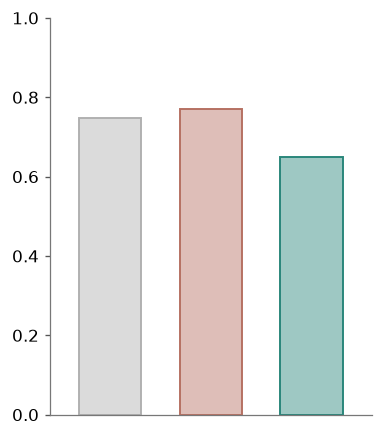

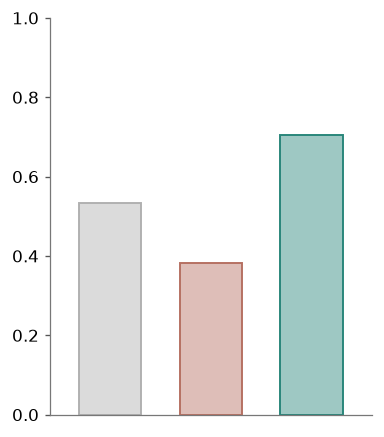

,scenario_name,scenario,R2,PearsonR,MAE,RMSE,n_external
0,target_only,Target-only baseline,0.187802,0.532516,0.747288,0.857183,103
1,mechanism_mismatched_transfer,Mechanism-mismatched transfer,0.122623,0.382323,0.770646,0.890914,103
2,mechanism_aligned_transfer,Mechanism-aligned transfer,0.385587,0.704195,0.650289,0.745544,103


SHOW_TEXT = False; output suffix: _no_text
Saved vertical metric bars to /home/syz/ru-mechanism-transfer/results/2_1_recent_aho_external_validation/figures


In [9]:
# SHOW_TEXT and SHOW_LEGEND are controlled in the setup cell.
# False hides editorial text; numeric ticks remain.

# Vertical metric bars; prediction/model selection is unchanged.
from matplotlib.colors import to_rgb
from matplotlib.ticker import MultipleLocator

PLOT_SCENARIO_ORDER = [TARGET_ONLY_NAME, DIFF_MECH_NAME, SAME_MECH_NAME]
PLOT_LABEL_MAP = {
    TARGET_ONLY_NAME: 'Target-only baseline',
    DIFF_MECH_NAME: 'Mechanism-mismatched transfer',
    SAME_MECH_NAME: 'Mechanism-aligned transfer',
}
# Recalculate from the full, unmodified prediction arrays, not rounded annotations.
external_metric_rows = []
for scenario_name in PLOT_SCENARIO_ORDER:
    pred = np.asarray(ensemble_predictions[scenario_name], dtype=float)
    if pred.shape != np.asarray(y_recent).shape or not np.isfinite(pred).all():
        raise ValueError(f'Invalid external predictions for {scenario_name}')
    external_metric_rows.append({'scenario_name': scenario_name,
                                'scenario': PLOT_LABEL_MAP[scenario_name],
                                **calc_metrics(y_recent, pred), 'n_external': len(y_recent)})
EXTERNAL_PLOT_METRICS_DF = pd.DataFrame(external_metric_rows)
EXTERNAL_PLOT_METRICS_DF.to_csv(TABLE_DIR / 'external_ensemble_plot_metrics.csv', index=False)


def pale_color(color, whiten=0.75):
    rgb = np.array(to_rgb(color))
    return tuple(rgb + whiten * (1-rgb))


def draw_external_metric_bars(axes, metrics_table, show_text=False, metric_specs=None):
    lookup = metrics_table.set_index('scenario_name')
    if metric_specs is None:
        metric_specs = [('MAE', 'MAE (kcal/mol)'), ('PearsonR', 'Pearson r')]
    for ax, (metric, title) in zip(axes, metric_specs):
        vals = np.array([lookup.loc[s,metric] for s in PLOT_SCENARIO_ORDER], dtype=float)
        colors = [SCENARIO_COLORS[s] for s in PLOT_SCENARIO_ORDER]
        bars = ax.bar(np.arange(3), vals, width=EXTERNAL_BAR_WIDTH,
                      color=[pale_color(c, EXTERNAL_BAR_LIGHTEN) for c in colors],
                      edgecolor=colors, linewidth=1.15)
        ax.set_xlim(-.6, 2.6)
        # Scenario colors are intended for a shared legend added during manual layout.
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=10, length=3, color='#555555')
        for spine in ['top','right']:
            ax.spines[spine].set_visible(False)
        for spine in ['bottom','left']:
            ax.spines[spine].set_color('#777777')
            ax.spines[spine].set_linewidth(.75)
        finite = vals[np.isfinite(vals)]
        if metric == 'PearsonR':
            ax.set_ylim(-1.0 if np.any(finite < 0) else 0.0, 1.0)
        else:
            upper = max(1.0, np.ceil(finite.max()*1.18*10)/10) if len(finite) else 1.0
            ax.set_ylim(0, upper)
        ax.yaxis.set_major_locator(MultipleLocator(.2))
        ax.grid(False)
        if show_text:
            ax.set_title(title, fontsize=12, pad=12)
            span = ax.get_ylim()[1]-ax.get_ylim()[0]
            for bar, val in zip(bars, vals):
                x = bar.get_x()+bar.get_width()/2
                if np.isfinite(val):
                    if val >= ax.get_ylim()[1]-.08*span:
                        y, va = val-.03*span, 'top'
                    elif val < 0 and val > ax.get_ylim()[0]+.08*span:
                        y, va = val-.025*span, 'top'
                    else:
                        y, va = val+.025*span, 'bottom'
                    ax.text(x, y, f'{val:.2f}', ha='center', va=va, fontsize=11, color='#222222')
                else:
                    ax.text(x, .02*span, 'NA', ha='center', va='bottom', fontsize=10)


def export_external_figure(fig, name):
    # Enforce the switch again immediately before saving/displaying the figure.
    if not SHOW_TEXT:
        for ax in fig.axes:
            for loc in ['left', 'center', 'right']:
                ax.set_title('', loc=loc)
            ax.set_xlabel(''); ax.set_ylabel('')
            for text in ax.texts:
                text.set_visible(False)
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        for text in fig.texts:
            text.set_visible(False)
    if SHOW_LEGEND:
        from matplotlib.patches import Patch
        fig.legend(handles=[Patch(facecolor=pale_color(SCENARIO_COLORS[k], EXTERNAL_BAR_LIGHTEN),
                                  edgecolor=SCENARIO_COLORS[k], label=PLOT_LABEL_MAP[k])
                            for k in PLOT_SCENARIO_ORDER],
                   loc='upper center', bbox_to_anchor=(.5, 0), frameon=False)
    name += '_with_text' if SHOW_TEXT else '_no_text'
    paths=[]
    for ext in ['svg']:
        path = FIGURE_DIR / f'{name}.{ext}'
        fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
        paths.append(path)
    plt.show()
    plt.close(fig)
    return paths

# Independent metric panels for manual layout; each file contains one axis.
EXTERNAL_METRIC_FIGURE_PATHS = []
for metric, title, file_tag in [
    ('MAE', 'MAE (kcal/mol)', 'mae'),
    ('PearsonR', 'Pearson r', 'pearson_r'),
]:
    fig, ax = plt.subplots(figsize=(3.4, 3.8))
    draw_external_metric_bars([ax], EXTERNAL_PLOT_METRICS_DF, SHOW_TEXT,
                              metric_specs=[(metric, title)])
    fig.subplots_adjust(left=.18, right=.97,
                        top=.87 if SHOW_TEXT else .97, bottom=.10)
    EXTERNAL_METRIC_FIGURE_PATHS.extend(export_external_figure(
        fig, f'external_{ENSEMBLE_TAG}_vertical_{file_tag}'))

display(EXTERNAL_PLOT_METRICS_DF)
print(f'SHOW_TEXT = {SHOW_TEXT}; output suffix: ' + ('_with_text' if SHOW_TEXT else '_no_text'))
print('Saved vertical metric bars to', FIGURE_DIR)


In [10]:
# =========================
# Direct result inspection
# External results are diagnostics only; they do not change the preselected members.
# =========================
for scenario in SCENARIO_LABELS.values():
    print(
        f"\n{scenario}: {ENSEMBLE_DISPLAY} internally selected "
        "members plus ensemble"
    )
    view = (
        compact_metrics_df.loc[compact_metrics_df["scenario"] == scenario]
        .sort_values(["R2", "MAE"], ascending=[False, True])
        .reset_index(drop=True)
    )
    display(view)

ensemble_result_names = [ensemble_result_name(name) for name in ENSEMBLE_SPECS]
error_columns = {
    result_name: f"abs_error_{safe_name(result_name)}"
    for result_name in ensemble_result_names
}

work = pred_df.copy()
work["external_row_index"] = work.index.astype(int)
work["best_ensemble_abs_error"] = work[list(error_columns.values())].min(axis=1)
work["best_error_ensemble"] = [
    min(error_columns, key=lambda name: float(row[error_columns[name]]))
    for _, row in work.iterrows()
]

same_result = ensemble_result_name(SAME_MECH_NAME)
work["same_mechanism_abs_error"] = work[error_columns[same_result]]
work["same_mechanism_ensemble_is_best"] = (
    work["same_mechanism_abs_error"] <= work["best_ensemble_abs_error"] + 1e-12
)
same_not_best = (
    work.loc[~work["same_mechanism_ensemble_is_best"]]
    .sort_values("same_mechanism_abs_error", ascending=False)
    .reset_index(drop=True)
)

front_cols = [
    "external_row_index", "Reaction Year", "best_error_ensemble",
    "same_mechanism_abs_error", "best_ensemble_abs_error", "y_true",
    "Reactant SMILES", "Product SMILES", "Ligand SMILES", "Solvent SMILES",
    "Additive SMILES", "Pressure/atm", "Temperature/C", "S/C",
]
front_cols += [f"pred_{safe_name(name)}" for name in ensemble_result_names]
front_cols += [error_columns[name] for name in ensemble_result_names]
front_cols = [col for col in front_cols if col in same_not_best.columns]

print(
    f"Rows where the mechanism-aligned {ENSEMBLE_DISPLAY} ensemble "
    f"is not the best of the {N_SCENARIOS} scenario ensembles:",
    len(same_not_best),
    "/",
    len(pred_df),
)
with pd.option_context("display.max_columns", None, "display.max_rows", 40, "display.width", 240):
    display(same_not_best[front_cols].head(40))



Target-only: 3 MACCS + 3 SPOC internally selected members plus ensemble


,scenario,result_type,rank_within_representation,overall_rank_from_internal_OOF,representation,model,strategy,internal_pooled_OOF_R2,R2,PearsonR,MAE,RMSE
0,Target-only,single model,2.0,6.0,MACCS,HGBR,Target-only,0.482109,0.306939,0.557546,0.666564,0.791824
1,Target-only,single model,3.0,7.0,MACCS,GBR,Target-only,0.467606,0.296740,0.579204,0.642295,0.797629
2,Target-only,ensemble,NaN,NaN,3 MACCS + 3 SPOC,3 MACCS + 3 SPOC ensemble mean,member-specific,NaN,0.187802,0.532516,0.747288,0.857183
3,Target-only,single model,1.0,4.0,MACCS,SVR,Target-only,0.495043,0.120893,0.560052,0.789567,0.891792
4,Target-only,single model,2.0,2.0,SPOC,HGBR,Target-only,0.542136,0.032855,0.290297,0.801383,0.935381
5,Target-only,single model,3.0,3.0,SPOC,RF,Target-only,0.500892,-0.046836,0.285957,0.844624,0.973155
6,Target-only,single model,1.0,1.0,SPOC,GBR,Target-only,0.621655,-0.299517,0.103785,0.946561,1.084261



Mechanism-aligned transfer: 3 MACCS + 3 SPOC internally selected members plus ensemble


,scenario,result_type,rank_within_representation,overall_rank_from_internal_OOF,representation,model,strategy,internal_pooled_OOF_R2,R2,PearsonR,MAE,RMSE
0,Mechanism-aligned transfer,ensemble,NaN,NaN,3 MACCS + 3 SPOC,3 MACCS + 3 SPOC ensemble mean,member-specific,NaN,0.385587,0.704195,0.650289,0.745544
1,Mechanism-aligned transfer,single model,1.0,1.0,SPOC,HGBR,Mixed,0.702908,0.020918,0.515148,0.852267,0.941136
2,Mechanism-aligned transfer,single model,3.0,3.0,SPOC,RF,Mixed,0.664338,0.002939,0.417470,0.836532,0.949738
3,Mechanism-aligned transfer,single model,1.0,4.0,MACCS,ExtraTrees,Mixed,0.640186,-0.118718,0.331598,0.890886,1.006012
4,Mechanism-aligned transfer,single model,2.0,6.0,MACCS,HGBR,Mixed,0.632018,-0.207526,0.515297,0.920965,1.045180
5,Mechanism-aligned transfer,single model,2.0,2.0,SPOC,ExtraTrees,Mixed,0.681813,-0.507507,0.288094,1.031350,1.167811
6,Mechanism-aligned transfer,single model,3.0,8.0,MACCS,DT,Delta,0.619220,-2.382589,0.739958,1.483999,1.749312



Mechanism-mismatched transfer: 3 MACCS + 3 SPOC internally selected members plus ensemble


,scenario,result_type,rank_within_representation,overall_rank_from_internal_OOF,representation,model,strategy,internal_pooled_OOF_R2,R2,PearsonR,MAE,RMSE
0,Mechanism-mismatched transfer,single model,2.0,10.0,MACCS,RF,Mixed,0.538061,0.137075,0.412370,0.764994,0.883546
1,Mechanism-mismatched transfer,ensemble,NaN,NaN,3 MACCS + 3 SPOC,3 MACCS + 3 SPOC ensemble mean,member-specific,NaN,0.122623,0.382323,0.770646,0.890914
2,Mechanism-mismatched transfer,single model,1.0,8.0,MACCS,SVR,Mixed,0.562458,0.122331,0.655389,0.785442,0.891062
3,Mechanism-mismatched transfer,single model,3.0,11.0,MACCS,SVR,Delta,0.507266,0.112246,0.541594,0.795068,0.896167
4,Mechanism-mismatched transfer,single model,3.0,3.0,SPOC,RF,Delta,0.617635,0.030952,0.267034,0.748426,0.936301
5,Mechanism-mismatched transfer,single model,2.0,2.0,SPOC,HGBR,Delta,0.637656,-0.082591,0.317366,0.701570,0.989635
6,Mechanism-mismatched transfer,single model,1.0,1.0,SPOC,RF,Mixed,0.649806,-0.351185,-0.023430,0.961562,1.105606


Rows where the mechanism-aligned 3 MACCS + 3 SPOC ensemble is not the best of the 3 scenario ensembles: 41 / 103


,external_row_index,Reaction Year,best_error_ensemble,same_mechanism_abs_error,best_ensemble_abs_error,y_true,Reactant SMILES,Product SMILES,Ligand SMILES,Solvent SMILES,Additive SMILES,Pressure/atm,Temperature/C,S/C,pred_target_only_3_maccs_3_spoc_ensemble_mean,pred_mechanism_aligned_transfer_3_maccs_3_spoc_ensemble_mean,pred_mechanism_mismatched_transfer_3_maccs_3_spoc_ensemble_mean,abs_error_target_only_3_maccs_3_spoc_ensemble_mean,abs_error_mechanism_aligned_transfer_3_maccs_3_spoc_ensemble_mean,abs_error_mechanism_mismatched_transfer_3_maccs_3_spoc_ensemble_mean
0,89,2024,Target-only | 3 MACCS + 3 SPOC ensemble mean,1.286839,1.113344,0.982473,C=C(CC(=O)c1ccccc1)C(=O)O,C[C@@H](CC(=O)c1ccccc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,[K+].[OH-],20.0,25.0,100.0,2.095817,2.269312,2.151679,1.113344,1.286839,1.169206
1,42,2024,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,1.110295,0.943136,3.136197,C=C(CC(=O)c1ccccc1)C(=O)O,C[C@@H](CC(=O)c1ccccc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],50.0,25.0,100.0,2.081909,2.025902,2.193060,1.054288,1.110295,0.943136
2,84,2024,Target-only | 3 MACCS + 3 SPOC ensemble mean,1.103539,0.967621,1.126287,C=C(CC(=O)c1ccccc1)C(=O)O,C[C@@H](CC(=O)c1ccccc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,[Na+].[OH-],20.0,25.0,100.0,2.093909,2.229826,2.146932,0.967621,1.103539,1.020645
3,39,2024,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,1.057514,0.814418,3.136197,C=C(CC(=O)c1ccccc1)C(=O)O,C[C@@H](CC(=O)c1ccccc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CO,O=C([O-])O.[Na+],50.0,25.0,100.0,2.215409,2.078682,2.321778,0.920788,1.057514,0.814418
4,15,2026,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,1.036969,0.729311,3.136197,C=C(CC(=O)c1cccc(Cl)c1)C(=O)O,C[C@@H](CC(=O)c1cccc(Cl)c1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,2.297883,2.099228,2.406886,0.838314,1.036969,0.729311
5,17,2026,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,1.036733,0.877644,3.136197,C=C(CC(=O)c1cccc(C(F)(F)F)c1)C(=O)O,C[C@@H](CC(=O)c1cccc(C(F)(F)F)c1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,2.091103,2.099464,2.258553,1.045094,1.036733,0.877644
6,9,2026,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,1.017005,0.805058,3.136197,C=C(CC(=O)c1ccc(Cl)cc1)C(=O)O,C[C@@H](CC(=O)c1ccc(Cl)cc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,2.290360,2.119192,2.331138,0.845836,1.017005,0.805058
7,11,2026,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,0.964818,0.875098,3.136197,C=C(CC(=O)c1ccc(C(F)(F)F)cc1)C(=O)O,C[C@@H](CC(=O)c1ccc(C(F)(F)F)cc1)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,2.110780,2.171379,2.261099,1.025417,0.964818,0.875098
8,60,2022,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,0.944361,0.279533,1.965138,C=C(OC)c1c(NC(=O)OC(C)(C)C)cnn2ccnc12,CO[C@@H](C)c1c(NC(=O)OC(C)(C)C)cnn2ccnc12,Cc1ccc(C(C)C)cc1.c1ccc(P(c2ccccc2)c2ccc3ccccc3...,ClCCl,,50.0,25.0,100.0,1.413879,1.020777,1.685605,0.551259,0.944361,0.279533
9,23,2026,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,0.923894,0.872961,3.136197,C=C(CC(=O)c1ccccc1C(F)(F)F)C(=O)O,C[C@@H](CC(=O)c1ccccc1C(F)(F)F)C(=O)O,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,CCO,O=C([O-])O.[Na+],20.0,25.0,100.0,2.092140,2.212303,2.263236,1.044056,0.923894,0.872961


## Figure outputs

Export the external selectivity-density curve and performance bars. Reaction schemes and literature timelines are assembled separately.
